## 5. Feature Spliting

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

INPUT_CANDIDATES = [
    Path("processed-data/anime.parquet"),
    Path("processed-data/anime.csv"),
]

OUT_DIR = Path("processed-data/splits")
OUT_DIR.mkdir(parents=True, exist_ok = True)

Load source dataset and validate schema.

In [5]:
src_path = None

for p in INPUT_CANDIDATES:
    if p.exists():
        src_path = p
        break

if src_path is None:
    raise FileNotFoundError("dataset is not found.")

if src_path.suffix.lower() == '.parquet':
    df = pd.read_parquet(src_path)
else:
    df = pd.read_csv(src_path, low_memory=False)

required_cols = ["username", "anime_id", "my_score", "last_updated_dt"]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Loaded:", src_path.resolve())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: C:\Users\escan\Documents\02-academics\25-26\term_2\stintsy\01-actual-folder\STINTSYMajorOutput\processed-data\anime.csv
Shape: (91209, 16)
Columns: ['username', 'anime_id', 'my_score', 'implicit_positive', 'my_status', 'last_updated_dt', 'episodes', 'score', 'popularity', 'favorites', 'user_watching', 'user_completed', 'user_onhold', 'user_dropped', 'user_plantowatch', 'user_days_spent_watching']


Filtering pipeline.

In [6]:
work = df.copy()

# Explicit ratings only
work["my_score"] = pd.to_numeric(work["my_score"], errors="coerce")
work = work[work["my_score"] >= 1].copy()

# Parse timestamp safely
work["last_updated_dt"] = pd.to_datetime(work["last_updated_dt"], errors="coerce")

# Keep only rows with valid and plausible timestamps for chronological split
before_ts = len(work)
work = work.dropna(subset=["last_updated_dt"]).copy()

min_valid_dt = pd.Timestamp("2000-01-01")
max_valid_dt = pd.Timestamp("2030-01-01")
out_of_range_mask = (work["last_updated_dt"] < min_valid_dt) | (work["last_updated_dt"] > max_valid_dt)
dropped_out_of_range = int(out_of_range_mask.sum())
work = work.loc[~out_of_range_mask].copy()

# Optional de-duplication: keep latest user-anime interaction
if {"username", "anime_id"}.issubset(work.columns):
    work = work.sort_values("last_updated_dt")
    work = work.drop_duplicates(subset=["username", "anime_id"], keep="last")

print("After rating filter + timestamp filter + dedup:")
print("Rows:", len(work))
print("Dropped invalid timestamp rows:", before_ts - len(work) - dropped_out_of_range)
print("Dropped out-of-range timestamp rows:", dropped_out_of_range)

After rating filter + timestamp filter + dedup:
Rows: 90544
Dropped invalid timestamp rows: 0
Dropped out-of-range timestamp rows: 665


Chronological split 70/15/15.

Split sizes
Train: (63380, 16)
Val: (13582, 16)
Test: (13582, 16)

Date ranges
Train: 2006-10-09 04:41:50 -> 2015-10-01 11:21:18
Val  : 2015-10-01 11:59:42 -> 2016-12-10 00:28:35
Test : 2016-12-10 01:16:59 -> 2018-05-20 23:47:25

Top 10 anime_id used for plotting: [11757, 8074, 2904, 5081, 10087, 226, 849, 5680, 19815, 6547]
Rows plotted -> Train: 797 Val: 65 Test: 59


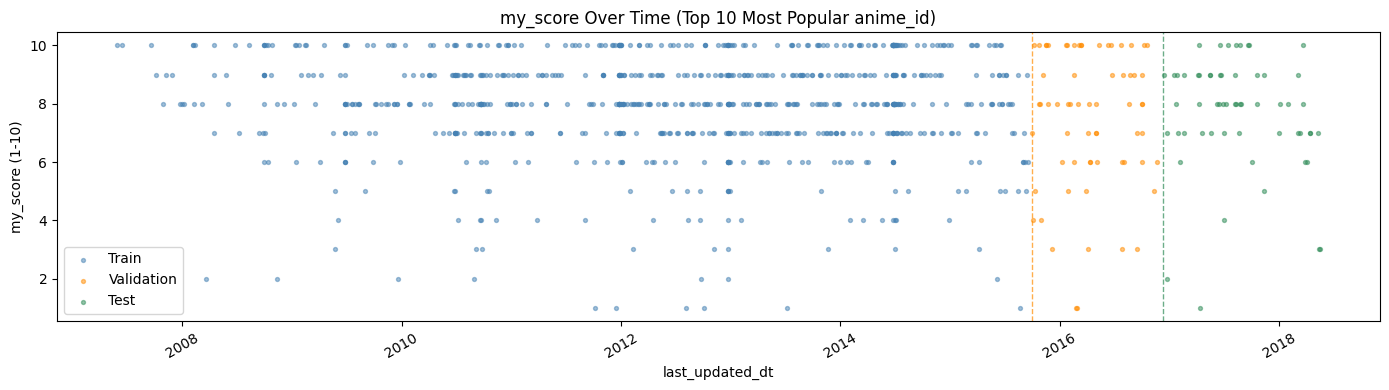

In [7]:
work = work.sort_values("last_updated_dt", kind="mergesort").reset_index(drop=True)

n = len(work)
i70 = int(n * 0.70)
i85 = int(n * 0.85)

train_df = work.iloc[:i70].copy()
val_df = work.iloc[i70:i85].copy()
test_df = work.iloc[i85:].copy()

print("Split sizes")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nDate ranges")
print("Train:", train_df["last_updated_dt"].min(), "->", train_df["last_updated_dt"].max())
print("Val  :", val_df["last_updated_dt"].min(), "->", val_df["last_updated_dt"].max())
print("Test :", test_df["last_updated_dt"].min(), "->", test_df["last_updated_dt"].max())

# Keep only the top 10 most popular anime_id values for visualization
top_10_anime_ids = work["anime_id"].value_counts().head(10).index
train_plot = train_df[train_df["anime_id"].isin(top_10_anime_ids)].copy()
val_plot = val_df[val_df["anime_id"].isin(top_10_anime_ids)].copy()
test_plot = test_df[test_df["anime_id"].isin(top_10_anime_ids)].copy()

print("\nTop 10 anime_id used for plotting:", list(top_10_anime_ids))
print("Rows plotted -> Train:", len(train_plot), "Val:", len(val_plot), "Test:", len(test_plot))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 4))

ax.scatter(train_plot["last_updated_dt"], train_plot["my_score"], color="steelblue",  label="Train",      s=8, alpha=0.5)
ax.scatter(val_plot["last_updated_dt"],   val_plot["my_score"],   color="darkorange", label="Validation", s=8, alpha=0.5)
ax.scatter(test_plot["last_updated_dt"],  test_plot["my_score"],  color="seagreen",   label="Test",       s=8, alpha=0.5)

ax.axvline(train_df["last_updated_dt"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(val_df["last_updated_dt"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("my_score Over Time (Top 10 Most Popular anime_id)")
ax.set_xlabel("last_updated_dt")
ax.set_ylabel("my_score (1-10)")
ax.legend()

# Auto locator/formatter improves readability across long timelines
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Validation checks before export.

In [10]:
# No overlap by row index after slicing sorted frame
assert len(train_df) + len(val_df) + len(test_df) == len(work)

# Basic target distribution sanity
print("my_score describe")
print("\nTrain\n", train_df["my_score"].describe())
print("\nVal\n", val_df["my_score"].describe())
print("\nTest\n", test_df["my_score"].describe())

# Required columns present in all splits
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    miss = [c for c in required_cols if c not in part.columns]
    if miss:
        raise ValueError(f"{name} split missing columns: {miss}")

print("\nValidation checks passed.")

my_score describe

Train
 count    63380.000000
mean         7.204228
std          1.749803
min          1.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: my_score, dtype: float64

Val
 count    13582.000000
mean         6.939331
std          1.815226
min          1.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: my_score, dtype: float64

Test
 count    13582.000000
mean         6.926741
std          1.845639
min          1.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: my_score, dtype: float64

Validation checks passed.


Export exactly three CSV files.

In [11]:
train_csv = OUT_DIR / "anime_train.csv"
val_csv = OUT_DIR / "anime_val.csv"
test_csv = OUT_DIR / "anime_test.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Exported CSV files:")
print(train_csv.resolve())
print(val_csv.resolve())
print(test_csv.resolve())

Exported CSV files:
C:\Users\escan\Documents\02-academics\25-26\term_2\stintsy\01-actual-folder\STINTSYMajorOutput\processed-data\splits\anime_train.csv
C:\Users\escan\Documents\02-academics\25-26\term_2\stintsy\01-actual-folder\STINTSYMajorOutput\processed-data\splits\anime_val.csv
C:\Users\escan\Documents\02-academics\25-26\term_2\stintsy\01-actual-folder\STINTSYMajorOutput\processed-data\splits\anime_test.csv


Readback check (quick integrity confirmation).

In [12]:
train_check = pd.read_csv(train_csv, low_memory=False)
val_check = pd.read_csv(val_csv, low_memory=False)
test_check = pd.read_csv(test_csv, low_memory=False)

print("Readback shapes")
print("Train:", train_check.shape)
print("Val:", val_check.shape)
print("Test:", test_check.shape)

Readback shapes
Train: (63380, 16)
Val: (13582, 16)
Test: (13582, 16)
